# fixed-CO$_2$ metrics benchmark  & SAVING Module C output (only run `B. Module C, save all SSPs below`

This notebook benchmarks **Module B (IPCC analytical IRF)** vs **Module C (prospective decay)** under the **fixed-CO$_2$ approach**.

Supported metric families:
- `gwp`: fixed-CO$_2$ dpGWP, computed as `AGWP_gas / AGWP_CO2_fixed`
- `rf`: instantaneous radiative forcing
- `agwp`: cumulative radiative forcing

For `gwp`, this notebook includes the extra denominator step using `AGWP_CO2_fixed.xlsx`.


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10')
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

## configuration

In [2]:
# ---- choose metric family here ----
METRIC_KIND = "gwp"   # options: "gwp", "rf", "agwp"
EXPORT_OUTPUTS = True

In [3]:
# horizon setup
len_cf = 101
HORIZON_YEARS = np.arange(len_cf)

# scenarios and model years
ssps = ["119", "245", "585"]
MYs = [2030, 2040, 2050]
ghggass = ["CO2", "CH4", "N2O"]

# metric directories
metric_dir_modB = "../FaIR_dpCFs/output/metrics_2026-02-23/"
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"

# workbook naming
filename_template_modB = "agwp_dcf_gwp100_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

# fixed-CO2 denominator workbook (used only when METRIC_KIND == "gwp")
agwp_co2_fixed_file = "../AGWPCO2_fixed_IPCCAR6/AGWP_CO2_fixed.xlsx"
agwp_co2_fixed_col = "AGWP_CO2_fixed"

# plotting style
ssp_labels = {"119": "SSP1-1.9", "245": "SSP2-4.5", "585": "SSP5-8.5"}
ssp_colors = {"119": "#43dde6", "245": "#364f6b", "585": "#fc5185"}


In [4]:
def get_metric_meta(metric_kind: str):
    metric_kind = metric_kind.lower()

    if metric_kind == "gwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "suffix": "GWP",
            "value_label": "dpGWP",
            "panel_ylabel": "dpGWP (fixed CO$_2$ 2s)",
            "suptitle": "Benchmark of fixed-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dpGWP_fixedCO2",
            "nc_stub": "GWP",
            "needs_fixed_co2_denominator": True,
        }
    elif metric_kind == "rf":
        return {
            "sheet_template": "rf_pointvalue{gas}_{MY}",
            "suffix": "RF",
            "value_label": "instantaneous RF",
            "panel_ylabel": "Instantaneous RF",
            "suptitle": "Benchmark of fixed-CO$_2$ instantaneous RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dRF_fixedCO2",
            "nc_stub": "RF",
            "needs_fixed_co2_denominator": False,
        }
    elif metric_kind == "agwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "suffix": "AGWP",
            "value_label": "cumulative RF",
            "panel_ylabel": "Cumulative RF",
            "suptitle": "Benchmark of fixed-CO$_2$ cumulative RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dCRF_fixedCO2",
            "nc_stub": "CRF",
            "needs_fixed_co2_denominator": False,
        }
    else:
        raise ValueError("METRIC_KIND must be one of: 'gwp', 'rf', 'agwp'")

META = get_metric_meta(METRIC_KIND)
META


{'sheet_template': 'agwp_pointvalue{gas}_{MY}',
 'suffix': 'GWP',
 'value_label': 'dpGWP',
 'panel_ylabel': 'dpGWP (fixed CO$_2$ 2s)',
 'suptitle': 'Benchmark of fixed-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)',
 'export_stub': 'dpGWP_fixedCO2',
 'nc_stub': 'GWP',
 'needs_fixed_co2_denominator': True}

#### helper functions

In [5]:

def load_metric_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template):
    """
    Read metric point-value vectors from metric workbooks.
    Output:
        out[gas][ssp][MY] -> np.ndarray
    """
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                filename = filename_template.format(gas=gas, ssp=sp, MY=MY)
                cf_file = metric_dir / filename
                sheet_name = sheet_template.format(gas=gas, MY=MY)

                cf_df = pd.read_excel(cf_file, sheet_name=sheet_name)
                out[gas][f"ssp{sp}"][str(MY)] = pd.to_numeric(cf_df[gas], errors="coerce").to_numpy()

    return out


def load_fixed_co2_denominator(excel_file, value_col, len_cf=101):
    """
    Load the fixed AGWP[CO2, 2019]-style denominator for H = 1..100.
    Expected workbook structure follows AGWP_CO2_fixed.xlsx used in the earlier notebook.
    """
    df = pd.read_excel(excel_file)
    vals = pd.to_numeric(df[value_col], errors="coerce").to_numpy()
    vals = vals[:len_cf]
    denom = vals[1:len_cf]
    if len(denom) != len_cf - 1:
        raise ValueError(f"Fixed-CO2 denominator length mismatch: expected {len_cf-1}, got {len(denom)}")
    return denom


def compute_fixed_co2_gwp(metric_results_agwp, agwp_co2_fixed, len_cf=101):
    """
    Convert AGWP arrays to fixed-CO2 dpGWP arrays by dividing AGWP[gas, future pulse]
    by the fixed AGWP[CO2] denominator.
    Input arrays are expected to include H=0..100; output arrays keep H=1..100.
    """
    out = defaultdict(lambda: defaultdict(dict))

    for gas in metric_results_agwp:
        for ssp in metric_results_agwp[gas]:
            for my in metric_results_agwp[gas][ssp]:
                arr = np.asarray(metric_results_agwp[gas][ssp][my], dtype=float)
                arr_trimmed = arr[1:len_cf]
                out[gas][ssp][my] = arr_trimmed / agwp_co2_fixed

    return out


def build_metric_dataframe(metric_results, metric_suffix, strip_ssp_prefix=False, integer_dims=False, prepend_zero_row=False):
    """
    Build a wide dataframe indexed by SSP / ModelYear / Year.

    For fixed-CO2 GWP, metric_results typically contains H=1..100 only, so prepend_zero_row=True
    inserts Year=0 with zeros to match the existing BW2-LCIA export convention.
    """
    records = []

    ref_gas = list(metric_results.keys())[0]
    for ssp in metric_results[ref_gas].keys():
        for my in metric_results[ref_gas][ssp].keys():
            arr_len = len(metric_results[ref_gas][ssp][my])

            if prepend_zero_row:
                row0 = {"SSP": ssp, "ModelYear": my, "Year": 0}
                for gas in metric_results.keys():
                    row0[f"{gas}_{metric_suffix}"] = 0.0
                records.append(row0)
                year_start = 1
            else:
                year_start = 0

            for i in range(arr_len):
                row = {"SSP": ssp, "ModelYear": my, "Year": year_start + i}
                for gas in metric_results.keys():
                    row[f"{gas}_{metric_suffix}"] = metric_results[gas][ssp][my][i]
                records.append(row)

    df_out = pd.DataFrame(records)

    if strip_ssp_prefix:
        df_out["SSP"] = df_out["SSP"].astype(str).str.replace("ssp", "", regex=False)

    if integer_dims:
        df_out["ModelYear"] = pd.to_numeric(df_out["ModelYear"], errors="coerce").astype(int)
        df_out["Year"] = pd.to_numeric(df_out["Year"], errors="coerce").astype(int)

    return df_out.set_index(["SSP", "ModelYear", "Year"]).sort_index()


def export_metric_outputs(df_formatted, out_dir, excel_name, nc_name_full, nc_name_hpos):
    if not EXPORT_OUTPUTS:
        return None, None, None

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_formatted.to_excel(out_dir / excel_name, index=True)

    xr_full = df_formatted.to_xarray()
    xr_full.to_netcdf(out_dir / nc_name_full)

    df_hpos = df_formatted[~(df_formatted.index.get_level_values("Year") == 0)].copy()
    xr_hpos = df_hpos.to_xarray()
    xr_hpos.to_netcdf(out_dir / nc_name_hpos)

    return df_hpos, xr_full, xr_hpos
    

def wide_to_long_for_benchmark(df_wide, metric_suffix, value_label, approach_name):
    value_cols = [f"CO2_{metric_suffix}", f"CH4_{metric_suffix}", f"N2O_{metric_suffix}"]

    long_df = (
        df_wide
        .reset_index()
        .melt(
            id_vars=["SSP", "ModelYear", "Year"],
            value_vars=value_cols,
            var_name="Gas",
            value_name=value_label,
        )
    )
    long_df["Gas"] = long_df["Gas"].str.replace(f"_{metric_suffix}", "", regex=False)
    long_df["Approach"] = approach_name
    return long_df


def plot_single_metric_panels(df_metric, ylabel=None):
    gas_order = ["CO2", "CH4", "N2O"]
    my_order = [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_metric[(df_metric["Gas"] == gas) & (df_metric["ModelYear"] == my)].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                if s.empty:
                    continue
                ax.plot(s["Year"], s["value"], color=ssp_colors[ssp], linewidth=1.8)

            ax.set_title(f"{gas}, MY={my}", fontsize=11)
            ax.set_xlabel("Horizon year")
            if c == 0:
                ax.set_ylabel(ylabel)
            ax.grid(False)

    ssp_handles = [
        Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k])
        for k in ["119", "245", "585"]
    ]

    fig.legend(
        handles=ssp_handles,
        loc="upper center",
        fontsize=13,
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        frameon=True,
        title="Scenario"
    )

    fig.subplots_adjust(top=0.88, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()


def build_benchmark_dataframe(df_modB, df_modC, metric_suffix, value_label):
    long_modB = wide_to_long_for_benchmark(df_modB, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module B")
    long_modC = wide_to_long_for_benchmark(df_modC, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module C")

    for df_long in [long_modB, long_modC]:
        df_long["SSP"] = df_long["SSP"].astype(str).str.strip().str.replace("ssp", "", regex=False)
        df_long["Gas"] = df_long["Gas"].astype(str).str.strip()
        df_long["ModelYear"] = pd.to_numeric(df_long["ModelYear"], errors="coerce").astype(int)
        df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype(int)

    benchmark_df = (
        long_modB
        .merge(
            long_modC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
        .drop(columns=["Approach_ModB", "Approach_ModC"])
    )

    benchmark_df["abs_diff"] = benchmark_df[f"{value_label}_ModC"] - benchmark_df[f"{value_label}_ModB"]
    benchmark_df["abs_diff_abs"] = benchmark_df["abs_diff"].abs()
    benchmark_df["pct_diff_vs_ModB"] = np.where(
        benchmark_df[f"{value_label}_ModB"] != 0,
        100 * benchmark_df["abs_diff"] / benchmark_df[f"{value_label}_ModB"],
        np.nan,
    )
    benchmark_df["pct_diff_abs"] = benchmark_df["pct_diff_vs_ModB"].abs()

    return benchmark_df


def summarize_benchmark(benchmark_df):
    summary_stats = (
        benchmark_df
        .groupby(["Gas", "SSP", "ModelYear"])
        .agg(
            mean_abs_diff=("abs_diff", "mean"),
            max_abs_diff=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff=("pct_diff_abs", "max"),
        )
        .reset_index()
    )

    summary_by_gas = (
        benchmark_df
        .groupby(["Gas"])
        .agg(
            mean_abs_diff=("abs_diff", "mean"),
            max_abs_diff=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff=("pct_diff_abs", "max"),
        )
        .reset_index()
    )

    return summary_stats, summary_by_gas



def plot_benchmark_3x3(benchmark_df, value_label, panel_ylabel, suptitle):
    gas_order = ["CO2", "CH4", "N2O"]
    my_order = [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = benchmark_df[
                (benchmark_df["Gas"] == gas) &
                (benchmark_df["ModelYear"] == my) &
                (benchmark_df["Year"] > 0)
            ].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                if s.empty:
                    continue

                color = ssp_colors[ssp]
                ax.plot(s["Year"], s[f"{value_label}_ModB"], linestyle="--", color=color, linewidth=1.8)
                ax.plot(s["Year"], s[f"{value_label}_ModC"], linestyle="-", color=color, linewidth=1.8)

            ax.set_title(f"{gas}, MY={my}", fontsize=11)
            ax.set_xlabel("Horizon year")
            if c == 0:
                ax.set_ylabel(panel_ylabel)
            ax.grid(False)

    ssp_handles = [
        Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k])
        for k in ["119", "245", "585"]
    ]

    method_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='IPCC analytical IRF'),
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='prospective decay'),
    ]


    # Scenario legend (left)
    fig.legend(
        handles=ssp_handles,
        loc='upper center',
        fontsize = 13,
        bbox_to_anchor=(0.36, 0.95),
        ncol=3,
        frameon=True,
        title="Scenario"
    )

    # Method legend (right)
    fig.legend(
        handles=method_handles,
        loc='upper center',
        fontsize = 13,
        bbox_to_anchor=(0.7, 0.95),
        ncol=2,
        frameon=True,
        title="Metric calculation"
    )


    fig.suptitle(suptitle, fontsize=15)
    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)

    
    if EXPORT_OUTPUTS:
        out_dir=f"output_{META['export_stub']}_modC",
        fig.savefig(
            out_dir / f"{metric_kind}_benchmark_ModuleBvsC_3x3.png",
            dpi=300,
            bbox_inches="tight"
        )
        
    plt.show()


## A. Module B

In [6]:

if META["needs_fixed_co2_denominator"]:
    agwp_results_modB = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template="agwp_pointvalue{gas}_{MY}",
    )
    agwp_co2_fixed = load_fixed_co2_denominator(
        excel_file=agwp_co2_fixed_file,
        value_col=agwp_co2_fixed_col,
        len_cf=len_cf,
    )
    metric_results_modB = compute_fixed_co2_gwp(
        metric_results_agwp=agwp_results_modB,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
else:
    metric_results_modB = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template=META["sheet_template"],
    )

# quick spot checks
metric_results_modB["CO2"]["ssp119"]["2030"][:5], metric_results_modB["CH4"]["ssp119"]["2030"][:5]


(array([0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393]),
 array([128.64236629, 126.92820887, 124.9856947 , 122.85409284,
        120.57092092]))

In [7]:

df_modB = build_metric_dataframe(
    metric_results=metric_results_modB,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)

if EXPORT_OUTPUTS:
    _, xr_modB_full, xr_modB_hpos = export_metric_outputs(
        df_formatted=df_modB,
        out_dir=f"output_{META['export_stub']}_modB",
        excel_name=f"{META['export_stub']}_CO2CH4N2O_modB.xlsx",
        nc_name_full=f"CF_{META['nc_stub']}0_100_perSSP_MY_majorghgs_ModB.nc",
        nc_name_hpos=f"CF_{META['nc_stub']}1_100_perSSP_MY_majorghgs_ModB.nc",
    )

print(df_modB.shape)
df_modB.head()


(909, 3)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.945684  128.642366  170.949474
              2     0.945684  126.928209  175.554756
              3     0.945684  124.985695  179.799718
              4     0.945684  122.854093  183.662784

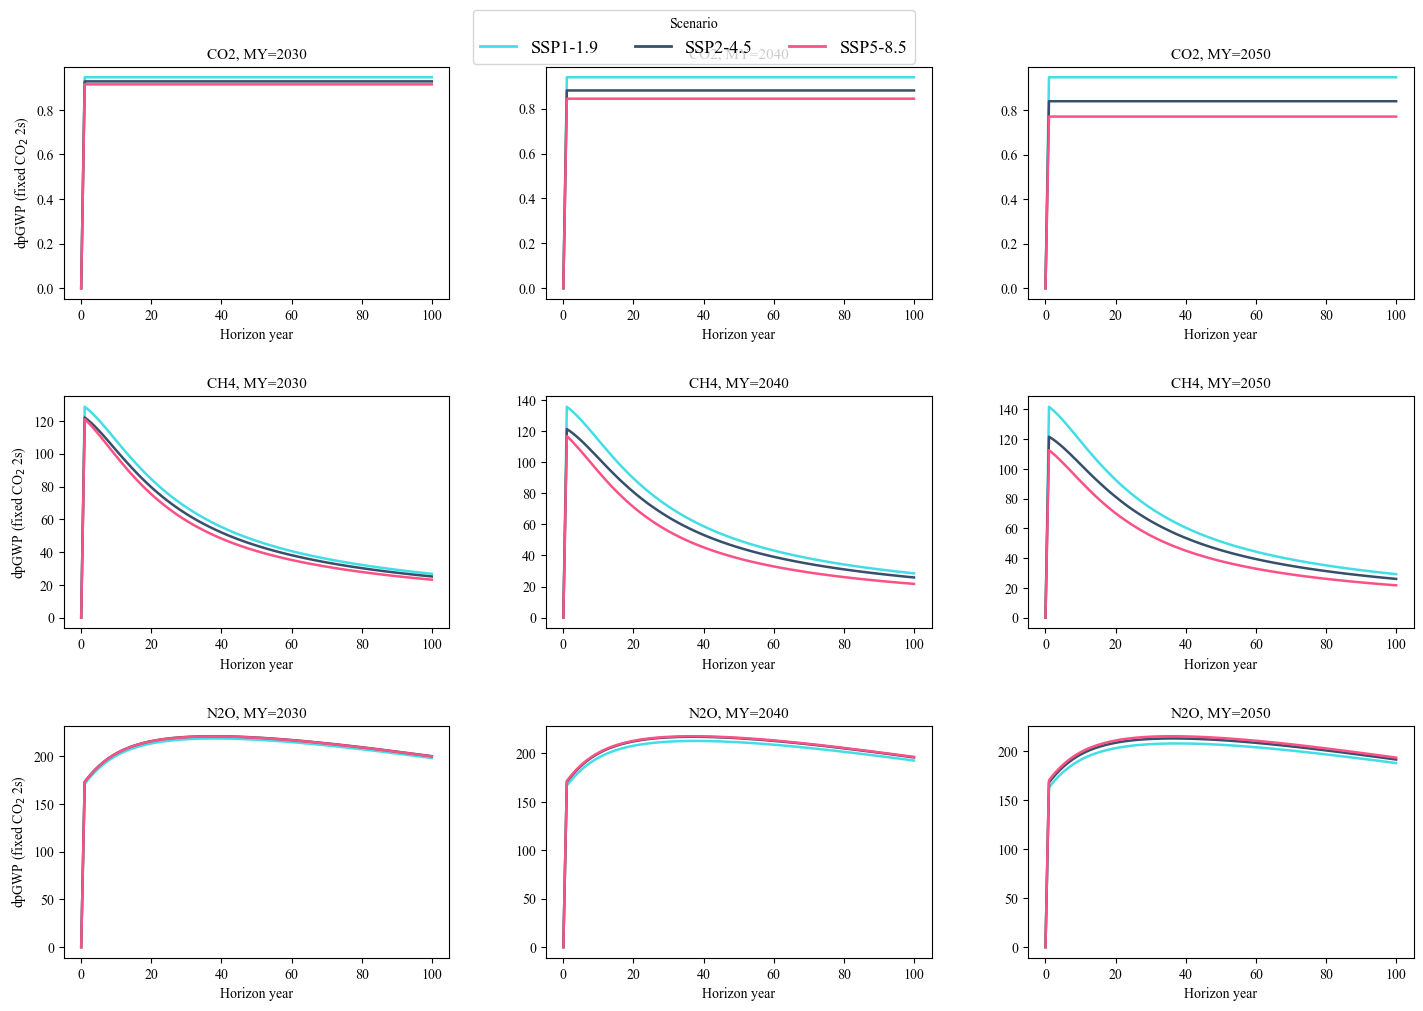

In [8]:

long_modB_preview = wide_to_long_for_benchmark(
    df_modB, metric_suffix=META["suffix"], value_label="value", approach_name="Module B"
)
plot_single_metric_panels(
    df_metric=long_modB_preview,
    ylabel=META["panel_ylabel"],
)


## B. Module C, SAVE all SSPs

In [6]:
ssps = ["119", "126", "245","434", "460",  "585"]

In [7]:
if META["needs_fixed_co2_denominator"]:
    agwp_results_modC = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template="agwp_pointvalue{gas}_{MY}",
    )
    agwp_co2_fixed = load_fixed_co2_denominator(
        excel_file=agwp_co2_fixed_file,
        value_col=agwp_co2_fixed_col,
        len_cf=len_cf,
    )
    metric_results_modC = compute_fixed_co2_gwp(
        metric_results_agwp=agwp_results_modC,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
    
else:
    metric_results_modC = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template=META["sheet_template"],
    )

metric_results_modC["CO2"]["ssp119"]["2030"][:5], metric_results_modC["CH4"]["ssp119"]["2030"][:5]


(array([0.94182202, 0.93933542, 0.94031372, 0.94199746, 0.94528235]),
 array([129.47472177, 128.41546872, 127.03372144, 125.36034275,
        123.48621965]))

In [8]:
df_modC = build_metric_dataframe(
    metric_results=metric_results_modC,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)


if EXPORT_OUTPUTS:
    _, xr_modC_full, xr_modC_hpos = export_metric_outputs(
        df_formatted=df_modC,
        out_dir=f"output_{META['export_stub']}_modC",
        excel_name=f"{META['export_stub']}_CO2CH4N2O_modC.xlsx",
        nc_name_full=f"fixedCO2_CF_{META['nc_stub']}0_100_perSSP_MY_majorghgs_ModC.nc",
        nc_name_hpos=f"fixedCO2_CF_{META['nc_stub']}1_100_perSSP_MY_majorghgs_ModC.nc",
    )

print(df_modC.shape)
df_modC.head()


(1818, 3)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.941822  129.474722  170.824170
              2     0.939335  128.415469  175.169989
              3     0.940314  127.033721  179.096258
              4     0.941997  125.360343  182.631564

## C. Benchmark Module B vs Module C

In [12]:

benchmark_df = build_benchmark_dataframe(
    df_modB=df_modB,
    df_modC=df_modC,
    metric_suffix=META["suffix"],
    value_label=META["value_label"],
)

print("benchmark_df shape:", benchmark_df.shape)
display(benchmark_df.head(12))


benchmark_df shape: (2727, 10)


,SSP,ModelYear,Year,Gas,dpGWP_ModB,dpGWP_ModC,abs_diff,abs_diff_abs,pct_diff_vs_ModB,pct_diff_abs
0,119,2030,0,CO2,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,119,2030,1,CO2,0.945684,0.941822,-0.003862,0.003862,-0.408372,0.408372
2,119,2030,2,CO2,0.945684,0.939335,-0.006349,0.006349,-0.671315,0.671315
3,119,2030,3,CO2,0.945684,0.940314,-0.005370,0.005370,-0.567866,0.567866
4,119,2030,4,CO2,0.945684,0.941997,-0.003686,0.003686,-0.389821,0.389821
5,119,2030,5,CO2,0.945684,0.945282,-0.000402,0.000402,-0.042465,0.042465
6,119,2030,6,CO2,0.945684,0.949163,0.003479,0.003479,0.367873,0.367873
7,119,2030,7,CO2,0.945684,0.952802,0.007118,0.007118,0.752697,0.752697
8,119,2030,8,CO2,0.945684,0.956579,0.010895,0.010895,1.152112,1.152112
9,119,2030,9,CO2,0.945684,0.959903,0.014219,0.014219,1.503534,1.503534


In [13]:

summary_stats, summary_by_gas = summarize_benchmark(benchmark_df)

display(summary_stats)
display(summary_by_gas)


,Gas,SSP,ModelYear,mean_abs_diff,max_abs_diff,mean_pct_diff,max_pct_diff
0,CH4,119,2030,3.540922,5.211713,7.227831,9.808673
1,CH4,119,2040,1.555021,2.634625,2.890138,4.406730
2,CH4,119,2050,0.420280,1.286884,0.690116,1.841288
3,CH4,245,2030,7.837824,10.552986,17.695561,23.339348
4,CH4,245,2040,6.625593,9.053613,14.455485,18.863071
...,...,...,...,...,...,...,...
22,N2O,245,2040,-12.560703,19.697973,-6.088069,10.056725
23,N2O,245,2050,-12.381837,19.148873,-6.124342,9.997428
24,N2O,585,2030,-12.894386,21.224505,-6.147004,10.629904
25,N2O,585,2040,-12.926731,21.338784,-6.255296,10.866920


,Gas,mean_abs_diff,max_abs_diff,mean_pct_diff,max_pct_diff
0,CH4,5.748603,13.158521,13.469795,32.095536
1,CO2,0.137345,0.478127,16.118089,61.059900
2,N2O,-11.919373,21.425923,-5.802664,11.072703


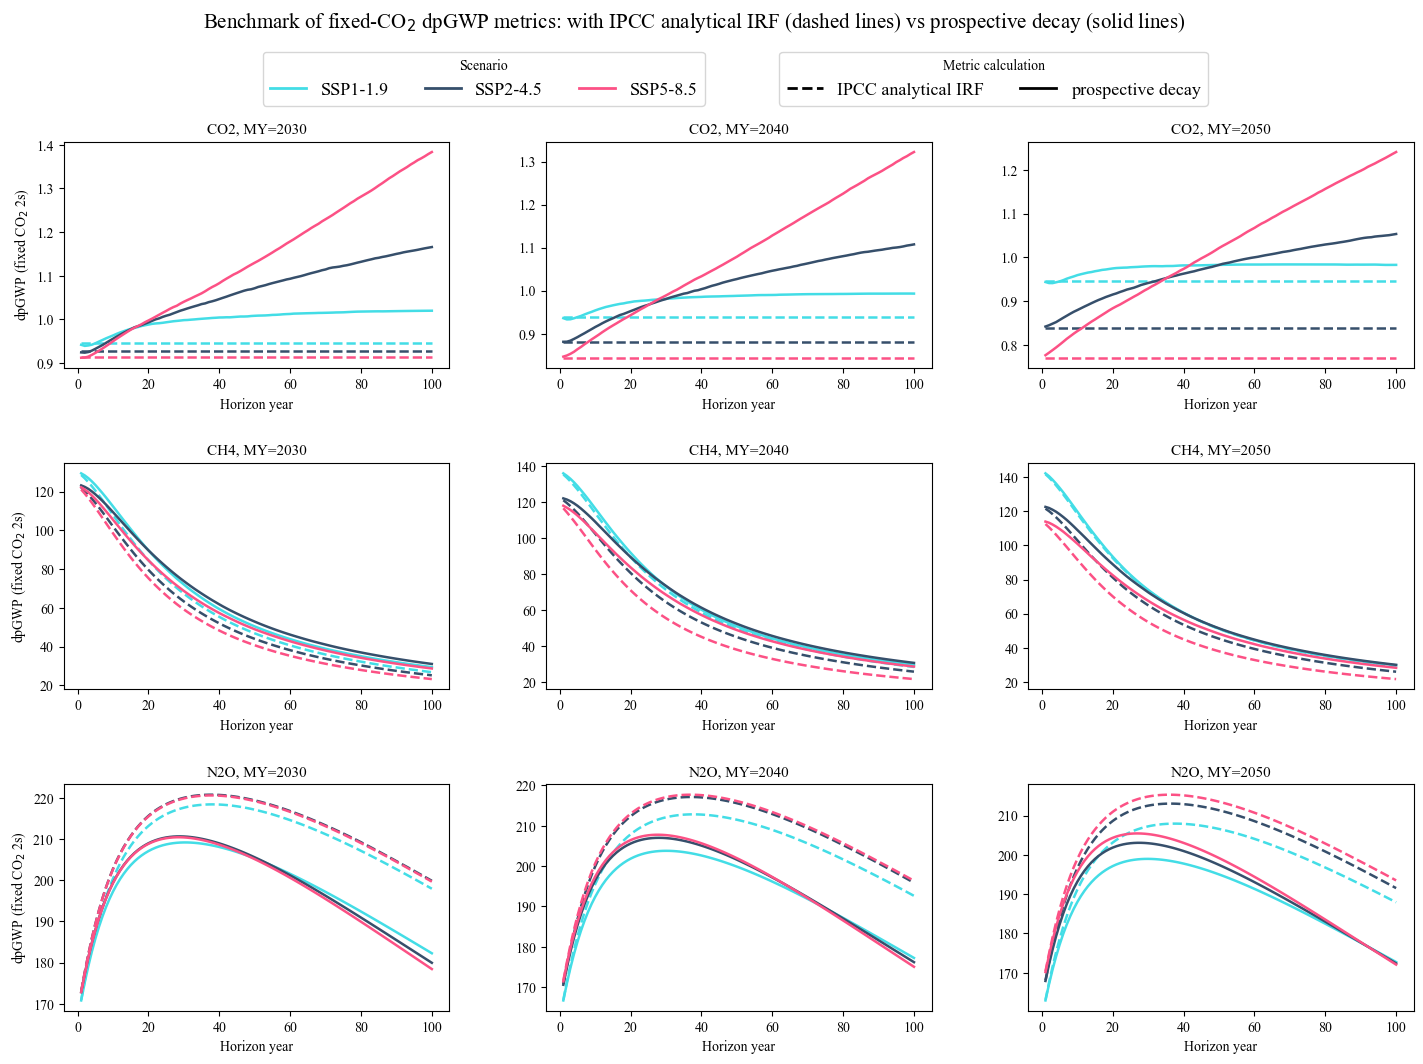

In [16]:

plot_benchmark_3x3(
    benchmark_df=benchmark_df,
    value_label=META["value_label"],
    panel_ylabel=META["panel_ylabel"],
    suptitle=META["suptitle"],
)


## Notes

- For `METRIC_KIND = "gwp"`, this notebook does **one extra calculation step** compared with the dp-CO$_2$ notebook:
  - load `agwp_pointvalue...` sheets,
  - load `AGWP_CO2_fixed.xlsx`,
  - compute `fixed-CO$_2$ dpGWP = AGWP_gas / AGWP_CO2_fixed`,
  - then prepend `Year = 0` as zeros for export consistency.

- For `METRIC_KIND = "rf"` or `"agwp"`, there is **no additional denominator step**. The notebook directly loads:
  - `rf_pointvalue{gas}_{MY}` for instantaneous RF
  - `agwp_pointvalue{gas}_{MY}` for cumulative RF

- This notebook is the fixed-CO$_2$ counterpart to the function-based dp-CO$_2$ notebook.
